In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

from scipy.stats import binom
from scipy.optimize import curve_fit
import sys

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['font.family'] = 'serif'



In [2]:
def energy_resolution_FWHM(sigma: float, mu: float) -> float:
    '''
    Computes the energy resolution (FWHM) of a Gaussian distribution given its standard deviation (sigma) and mean (mu).
    ======= params =======
    sigma, float: standard deviation of the Gaussian distribution
    mu, float: mean of the Gaussian distribution
    ======= returns =======
    FWHM, float: Full Width at Half Maximum of the Gaussian distribution
    '''
    return sigma * 2 *np.sqrt(2 * np.log(2)) / mu

def gaussian(x: float, A: float, sigma: float, mu: float) -> float:
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# 1. Lectura de los datos en chunks

El documento es demasiado grande como para leerlo todo conjunto en memoria, de forma que se abre en secciones.

In [3]:
mode = 'absorbent'  # Options: 'reflective', 'absorbent'
event = 'Kr_41.5keV'  # Options: 'KalphaLine_29.7keV', 'Kr_41.5keV', 'blob_300keV'
sipm_size = 3  # Options: 3, 6 (in mm)

if mode == 'reflective':
    switch = 'on'
else:
    switch = 'off'
    
field = 1.2 # Options: 1.8, 1.4 (in kV/cm/bar)
savefigs = True  # Set to True to save figures, False to display them only

In [4]:
path =f'/Volumes/EXTERNAL_US/GALA_data/geometric_hits_{mode}GALA_5mm_{field}kVcmbar_{event}_{sipm_size}mmSiPM.txt'

# path = '/Users/pablovazquez/GALA_hole/build/geometric_hits_reflectiveGALA_5mm_2.4kVcmbar_KalphaLine_29.7keV_3mmSiPM_TEST.txt'

In [5]:
usecols = ['event_id', 'time_ns', 'vx_mm', 'vy_mm', 'vz_mm', 'nPhotons']

chunksize = 200_000
sampling = 200

# Primera pasada: rango temporal global y radio máximo por evento
time_min = np.inf
time_max = -np.inf
radius_by_event = {}
photons_generated_by_event = {}
vz_by_event = {}
vx_by_event = {}
vy_by_event = {}

for chunk in pd.read_csv(path, sep=r'\s+', usecols = usecols, chunksize = chunksize):
    chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2)
    time_min = min(time_min, chunk['time_ns'].min())
    time_max = max(time_max, chunk['time_ns'].max())

    grouped = chunk.groupby('event_id', sort=False)
    max_radius = grouped['vR_mm'].max()
    for event_id, r_max in max_radius.items():
        radius_by_event[event_id] = max(radius_by_event.get(event_id, 0.0), float(r_max))
    
    # Guardar fotones generados (tomar el primero de cada evento, ya que es el mismo para todo el evento)
    n_photons = grouped['nPhotons'].first()
    for event_id, n_phot in n_photons.items():
        photons_generated_by_event[event_id] = int(n_phot)
    
    vz = grouped['vz_mm'].first()
    for event_id, z in vz.items():
        if event_id not in vz_by_event:
            vz_by_event[event_id] = float(z)

    vx = grouped['vx_mm'].first()
    for event_id, x in vx.items():
        if event_id not in vx_by_event:
            vx_by_event[event_id] = float(x)

    vy = grouped['vy_mm'].first()
    for event_id, y in vy.items():
        if event_id not in vy_by_event:
            vy_by_event[event_id] = float(y)

# Definir bins temporales globales
n_bins = int(np.ceil((time_max - time_min) / sampling))
bins = np.linspace(time_min, time_max, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Segunda pasada: construir conteos por evento y bin
per_event_bin_counts = {}
photons_by_event = {}
hist = np.zeros(n_bins, dtype=int)

for chunk in pd.read_csv(path, sep=r'\s+', usecols=usecols, chunksize=chunksize):
    try:
        chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2 + chunk['vz_mm']**2)
        chunk['bin_index'] = np.digitize(chunk['time_ns'], bins) - 1
        chunk = chunk[(chunk['bin_index'] >= 0) & (chunk['bin_index'] < n_bins)]

        hist += np.histogram(chunk['time_ns'].to_numpy(), bins=bins)[0]

        for (event_id, bin_index), group in chunk.groupby(['event_id', 'bin_index'], sort=False):
            event_bins = per_event_bin_counts.setdefault(int(event_id), np.zeros(n_bins, dtype=int))
            n_hits = int(len(group))
            event_bins[int(bin_index)] += n_hits
            photons_by_event[event_id] = photons_by_event.get(event_id, 0) + n_hits
    except Exception as e:
        print(f"Error processing chunk: {e}")
        continue

# Construir tabla resumida por evento para compatibilidad con el resto del notebook
sorted_event_ids = np.array(sorted(photons_by_event.keys()))
photons = np.array([photons_by_event[eid] for eid in sorted_event_ids])
radius = np.array([radius_by_event[eid] for eid in sorted_event_ids])
photons_generated = np.array([photons_generated_by_event.get(eid, 0) for eid in sorted_event_ids])

charge_binned = pd.DataFrame({
    'bin_center_ns': bin_centers,
    'n_hits': hist,
})

vz = np.array([vz_by_event.get(eid, np.nan) for eid in sorted_event_ids])
vx = np.array([vx_by_event.get(eid, np.nan) for eid in sorted_event_ids])
vy = np.array([vy_by_event.get(eid, np.nan) for eid in sorted_event_ids])

df_hits = pd.DataFrame({
    'event_id': sorted_event_ids,
    'photons': photons,
    'photons_generated': photons_generated,
    'radius': radius,
    'vz_mm': vz,
    'vx_mm': vx,
    'vy_mm': vy,
})
event_bin_rows = []
for event_id in sorted_event_ids:
    counts = per_event_bin_counts.get(int(event_id), np.zeros(n_bins, dtype=int))
    non_zero_bins = np.where(counts > 0)[0]
    for bin_index in non_zero_bins:
        event_bin_rows.append({
    'event_id': int(event_id),
    'bin_index': int(bin_index),
    'bin_center_ns': float(bin_centers[bin_index]),
    'n_hits': int(counts[bin_index]),
    'radius': float(radius_by_event[int(event_id)]),
    'vz_mm': float(vz_by_event.get(int(event_id), np.nan)),  # <-- añadir
    'vx_mm': float(vx_by_event.get(int(event_id), np.nan)),  # <-- añadir
    'vy_mm': float(vy_by_event.get(int(event_id), np.nan)),  # <-- añadir
})

event_bins_df = pd.DataFrame(event_bin_rows)

print(f'Hits/eventos procesados en chunks: {len(sorted_event_ids):,}')
print(f'Rango temporal global: {time_min:.6f} ns a {time_max:.6f} ns')
print(f'Hits totales acumulados: {hist.sum():,}')
print(f'Bins temporales: {n_bins:,}')
event_bins_df.head()

Hits/eventos procesados en chunks: 10,000
Rango temporal global: 7490.910000 ns a 16406.800000 ns
Hits totales acumulados: 101,438,135
Bins temporales: 45


,event_id,bin_index,bin_center_ns,n_hits,radius,vz_mm,vx_mm,vy_mm
0,0,8,9175.022556,1,0.698392,-1.72336,-0.55017,-0.430191
1,0,9,9373.153444,2,0.698392,-1.72336,-0.55017,-0.430191
2,0,10,9571.284333,3,0.698392,-1.72336,-0.55017,-0.430191
3,0,11,9769.415222,21,0.698392,-1.72336,-0.55017,-0.430191
4,0,12,9967.546111,20,0.698392,-1.72336,-0.55017,-0.430191


In [6]:
energy = event_bins_df.groupby('event_id')['n_hits'].sum().reset_index(name='total_hits')

In [7]:
energy['z'] = event_bins_df.groupby('event_id')['vz_mm'].first().values

In [8]:
df_hits = df_hits[df_hits['photons'] > 0]
df_hits['photons'] = df_hits['photons'] * (1- 0.5)

# 2. Cálculo de LCE

Definimos el número de fotones que se generan en el agujero de la GALA suponemos que una sigma del centro es lo que llega al agujero y tenemos en cuenta que para Xenon $W= 22.13\text{ eV}$ y el Kr genera $41.5 \text{ keV}$.

Cogemos los fotones generados en funcion de la distancia a la pared del agujero para entender los efectos de borde cerca de dicha pared

In [9]:
photons = df_hits['photons'].to_numpy()
radius = df_hits['radius'].to_numpy()
z = df_hits['vz_mm'].to_numpy()

In [10]:
# Calcular LCE (Light Collection Efficiency)
df_hits['lce'] = df_hits['photons'] / df_hits['photons_generated']

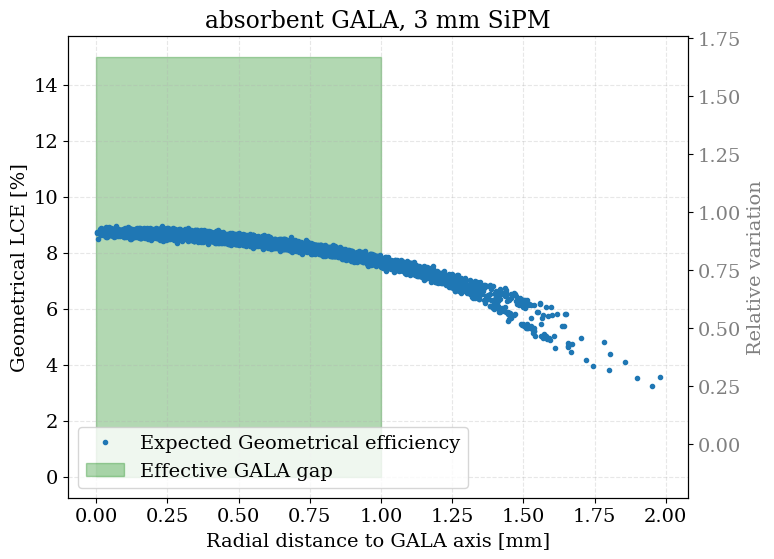

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(radius, df_hits.lce * 100, '.', label='Expected Geometrical efficiency')
ax1.fill_between((0, 1), (15, 15), alpha=0.3, color='green', label='Effective GALA gap')
ax1.set_title(f'{mode} GALA, {sipm_size} mm SiPM')
ax1.set_xlabel('Radial distance to GALA axis [mm]')
ax1.set_ylabel('Geometrical LCE [%]')
ax1.grid(True, alpha=0.3, linestyle='--')

lce_max = df_hits.lce.max() * 100  # en %
lce_min = df_hits.lce.min() * 100  # en %

ax2 = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2.set_ylim(ymin/lce_min, ymax/lce_max)
ax2.set_ylabel('Relative variation', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='lower left')
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/geometrical_lce_{mode}_{sipm_size}mm.png')

Se observa, ya geométricamente aparece una pérdida de LCE por el ángulo sólido en funcion de cuanto te alejas del centro de la GALA (suponiendo reflexiones al 68% o 95% aparece una muy alta LCE).

# 3. Efectos de la electrónica

Aplico efectos de la electrónica (dark counts, crosstalk, pde y variación en la ganancia de los SiPM para poder entender como afectan estos a la medida de la resolución)

In [12]:
pde = 0.23
sipm_reflectivity = 0.55
crosstalk_prob = 0.07
dark_count_rate_hz = 860000
microcells = 4774
gain_sigma_rel = 0.12
acquisition_window_ns = 200.0

Dichos efectos de la electrónica se aplican por bin temporal.

In [13]:
def compute_pde_bin(event_bins_df, prob_pde=pde, prob_crosstalk=crosstalk_prob,
                    dark_noise=dark_count_rate_hz, gain_sigma_rel=gain_sigma_rel,
                    acquisition_window_ns=acquisition_window_ns,
                    rng=None):
    """
    Procesa los bins temporales de un evento y aplica todas las etapas de electrónica.

    Cada fila de `event_bins_df` representa un bin temporal del evento con:
    - event_id
    - bin_index
    - bin_center_ns
    - n_hits
    - radius

    Retorna una fila por bin con:
    - n_pde
    - n_crosstalk
    - n_dark
    - charge_pe
    """

    if rng is None:
        rng = np.random.default_rng()

    if event_bins_df.empty or 'n_hits' not in event_bins_df.columns:
        return pd.DataFrame(columns=[
            'event_id', 'bin_index', 'bin_center_ns', 'radius', 'n_hits',
            'n_pde', 'n_crosstalk', 'n_dark', 'n_after_ct', 'n_after_dark', 'charge_pe'
        ])

    rows = []
    event_id = int(event_bins_df['event_id'].iloc[0])
    radius = float(event_bins_df['radius'].iloc[0])
    vz_mm = float(event_bins_df['vz_mm'].iloc[0])
    vx_mm = float(event_bins_df['vx_mm'].iloc[0])
    vy_mm = float(event_bins_df['vy_mm'].iloc[0])
    dark_mean = dark_noise * acquisition_window_ns * 1e-9

    for _, row in event_bins_df.sort_values('bin_index').iterrows():
        n_hits = int(row['n_hits'])
        bin_index = int(row['bin_index'])
        bin_center_ns = float(row['bin_center_ns'])
        
        n_entered = rng.binomial(n_hits, 1 - sipm_reflectivity)
        n_pde = min(rng.binomial(n_entered, prob_pde), microcells)
        n_crosstalk = rng.binomial(n_pde, prob_crosstalk)
        n_after_ct = min(n_pde + n_crosstalk, microcells)
        n_dark = rng.poisson(dark_mean)
        n_after_dark = min(n_after_ct + n_dark, microcells)
        k = n_after_dark/sampling/microcells
        correction = 1/(1+k*20)
        n_seen = n_after_dark * correction



        sigma_gain = gain_sigma_rel * np.sqrt(max(n_seen, 1))
        charge_pe = float(n_seen + rng.normal(0.0, sigma_gain))
        if charge_pe < 0.0:
            charge_pe = 0.0

        rows.append({
            'event_id': event_id,
            'bin_index': bin_index,
            'bin_center_ns': bin_center_ns,
            'radius': radius,
            'vz_mm': vz_mm,
            'vx_mm': vx_mm,
            'vy_mm': vy_mm,
            'n_hits': n_hits,
            'n_pde': n_pde,
            'n_crosstalk': n_crosstalk,
            'n_dark': n_dark,
            'n_after_ct': n_after_ct,
            'n_after_dark': n_after_dark,
            'charge_pe': charge_pe,
        })

    return pd.DataFrame(rows)

In [14]:
event_bins_df

,event_id,bin_index,bin_center_ns,n_hits,radius,vz_mm,vx_mm,vy_mm
0,0,8,9175.022556,1,0.698392,-1.72336,-0.550170,-0.430191
1,0,9,9373.153444,2,0.698392,-1.72336,-0.550170,-0.430191
2,0,10,9571.284333,3,0.698392,-1.72336,-0.550170,-0.430191
3,0,11,9769.415222,21,0.698392,-1.72336,-0.550170,-0.430191
4,0,12,9967.546111,20,0.698392,-1.72336,-0.550170,-0.430191
...,...,...,...,...,...,...,...,...
311427,9999,34,14326.425667,31,1.048843,-2.14073,0.683981,0.795136
311428,9999,35,14524.556556,16,1.048843,-2.14073,0.683981,0.795136
311429,9999,36,14722.687444,5,1.048843,-2.14073,0.683981,0.795136
311430,9999,37,14920.818333,2,1.048843,-2.14073,0.683981,0.795136


In [15]:
rng_electronics = np.random.default_rng()
resultados_electronica = []

for event_id, event_bins_df in event_bins_df.groupby('event_id', sort=True):
    event_result = compute_pde_bin(
        event_bins_df,
        prob_pde=pde,
        prob_crosstalk=crosstalk_prob,
        dark_noise=dark_count_rate_hz,
        gain_sigma_rel=gain_sigma_rel,
        acquisition_window_ns=acquisition_window_ns,
        rng=rng_electronics,
    )
    resultados_electronica.append(event_result)

charge_binned_electronica = pd.concat(resultados_electronica, ignore_index=True)
print(f'Eventos procesados: {charge_binned_electronica["event_id"].nunique():,}')
print(f'Filas bin-evento procesadas: {len(charge_binned_electronica):,}')
charge_binned_electronica.head()

Eventos procesados: 10,000
Filas bin-evento procesadas: 311,432


,event_id,bin_index,bin_center_ns,radius,vz_mm,vx_mm,vy_mm,n_hits,n_pde,n_crosstalk,n_dark,n_after_ct,n_after_dark,charge_pe
0,0,8,9175.022556,0.698392,-1.72336,-0.55017,-0.430191,1,0,0,0,0,0,0.000000
1,0,9,9373.153444,0.698392,-1.72336,-0.55017,-0.430191,2,0,0,0,0,0,0.000000
2,0,10,9571.284333,0.698392,-1.72336,-0.55017,-0.430191,3,1,0,0,1,1,0.963810
3,0,11,9769.415222,0.698392,-1.72336,-0.55017,-0.430191,21,2,0,0,2,2,1.679506
4,0,12,9967.546111,0.698392,-1.72336,-0.55017,-0.430191,20,2,0,0,2,2,2.032838


In [16]:
max_charge_time = []
max_charge_time_rms = []
max_charge = []

for event_id in charge_binned_electronica['event_id'].unique():
    event_data = charge_binned_electronica[charge_binned_electronica['event_id'] == event_id]
    max_charge.append(event_data['charge_pe'].max())
    time, charge = event_data['bin_center_ns'], event_data['charge_pe']
    popt, pcov = curve_fit(gaussian, time, charge, p0 = (400, 200, 12500))
    max_charge_time_rms.append(popt[1])
    max_charge_time.append(popt[2])


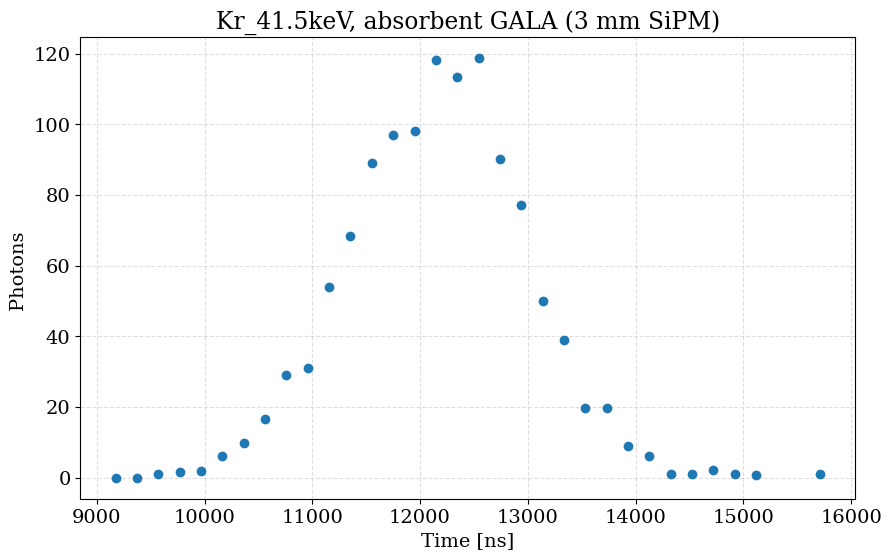

In [17]:
plt.plot(charge_binned_electronica[charge_binned_electronica.event_id==0].bin_center_ns, charge_binned_electronica[charge_binned_electronica.event_id==0]['charge_pe'], 'o');
# plt.plot(charge_binned_electronica[charge_binned_electronica.event_id==0].bin_center_ns, gaussian(charge_binned_electronica[charge_binned_electronica.event_id==0].bin_center_ns, max_charge[0], max_charge_time_rms[0], max_charge_time[0]), 'r-', linewidth=2);
plt.xlabel('Time [ns]');
plt.ylabel('Photons ');
plt.title(f'{event}, {mode} GALA ({sipm_size} mm SiPM)')
plt.grid(True, alpha = 0.4, linestyle = '--')
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/{event}_light_per_bin_{mode}_{sipm_size}mm.png')

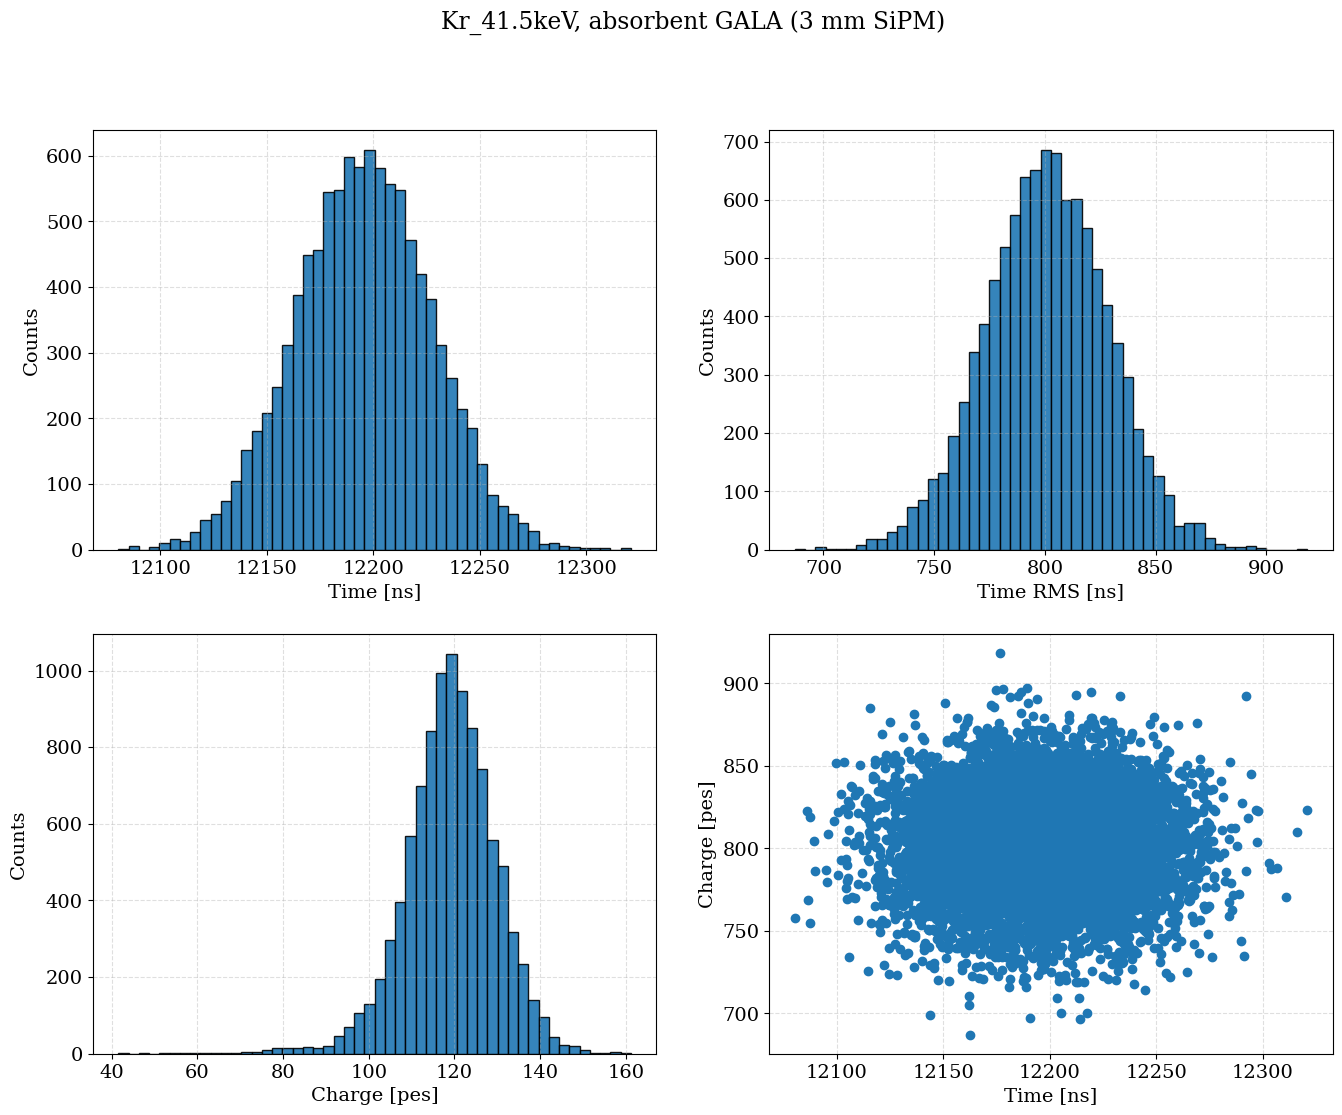

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{event}, {mode} GALA ({sipm_size} mm SiPM)')
ax[0, 0].hist(max_charge_time, bins = 50, alpha = .9, edgecolor = 'black');
ax[0, 0].set_xlabel('Time [ns]');
ax[0, 0].set_ylabel('Counts');
ax[0, 0].grid(True, alpha = 0.4, linestyle='--');

ax[0, 1].hist(max_charge_time_rms, bins = 50, alpha = .9, edgecolor = 'black');
ax[0, 1].set_xlabel('Time RMS [ns]');
ax[0, 1].set_ylabel('Counts');
ax[0, 1].grid(True, alpha = 0.4, linestyle='--');

ax[1, 0].hist(max_charge, bins = 50, alpha = .9, edgecolor = 'black');
ax[1, 0].set_xlabel('Charge [pes]');
ax[1, 0].set_ylabel('Counts');
ax[1, 0].grid(True, alpha = 0.4, linestyle='--');

ax[1, 1].plot(max_charge_time, max_charge_time_rms, 'o');
ax[1, 1].set_xlabel('Time [ns]');
ax[1, 1].set_ylabel('Charge [pes]');
ax[1, 1].grid(True, alpha = 0.4, linestyle='--');
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/{event}_charge_distribution_SiPM_{mode}_{sipm_size}mm.png')



In [19]:
0.03*615

18.45

In [20]:
np.max(charge_binned_electronica[charge_binned_electronica.event_id==0]['charge_pe'])

118.86257077418578

In [21]:
# Carga total por evento (sumando bins)
event_summary = (
    charge_binned_electronica
    .groupby('event_id', as_index=False)
    .agg(
        radius=('radius', 'first'),
        z_position=('vz_mm', 'first'),
        x_position=('vx_mm', 'first'),
        y_position=('vy_mm', 'first'),
        charge_pe=('charge_pe', 'sum'),
        n_hits=('n_hits', 'sum'),
        n_pde=('n_pde', 'sum'),
        n_crosstalk=('n_crosstalk', 'sum'),
        n_dark=('n_dark', 'sum'),
    )
)

charge_collection = event_summary['charge_pe'].to_list()
charge_collection_center = event_summary.loc[event_summary['radius'] < 0.9, 'charge_pe'].to_list()
charge_collection_center_1 = event_summary.loc[event_summary['radius'] < 1, 'charge_pe'].to_list()
charge_collection_center_2 = event_summary.loc[event_summary['radius'] < 0.6, 'charge_pe'].to_list()
charge_collection_center_3 = event_summary.loc[event_summary['radius'] < 1.2, 'charge_pe'].to_list()
charge_collection_center_4 = event_summary.loc[event_summary['radius'] < 1.4, 'charge_pe'].to_list()
charge_collection_center_5 = event_summary.loc[event_summary['radius'] < 0.5, 'charge_pe'].to_list()
charge_collection_center_6 = event_summary.loc[event_summary['radius'] < 0.7, 'charge_pe'].to_list()
charge_collection_center_7 = event_summary.loc[event_summary['radius'] < 0.8, 'charge_pe'].to_list()

print(f'Eventos totales: {len(charge_collection)}')
print(f'Eventos con radius < 0.7 mm: {len(charge_collection_center)}')

Eventos totales: 10000
Eventos con radius < 0.7 mm: 8489


In [22]:
event_summary

,event_id,radius,z_position,x_position,y_position,charge_pe,n_hits,n_pde,n_crosstalk,n_dark
0,0,0.698392,-1.723360,-0.550170,-0.430191,1172.632784,10114,1086,89,5
1,1,0.741989,-2.474170,0.371622,-0.642219,1162.628369,9996,1063,95,3
2,2,0.583503,-2.182990,0.581118,-0.052703,1185.495263,10566,1096,84,2
3,3,0.809587,-1.509460,0.048051,-0.808160,1034.531161,9659,972,53,7
4,4,0.489666,-2.455540,-0.447183,-0.199499,1166.661301,10381,1092,75,3
...,...,...,...,...,...,...,...,...,...,...
9995,9995,0.001655,-1.288490,-0.000788,-0.001456,1208.588010,10431,1134,65,9
9996,9996,0.501252,-0.621855,0.135268,0.482655,1139.712303,10452,1064,67,10
9997,9997,0.677119,-1.865160,0.336304,0.587699,1111.043296,10045,1032,81,4
9998,9998,0.218565,0.941137,-0.080641,-0.203145,1203.798052,10722,1134,70,4


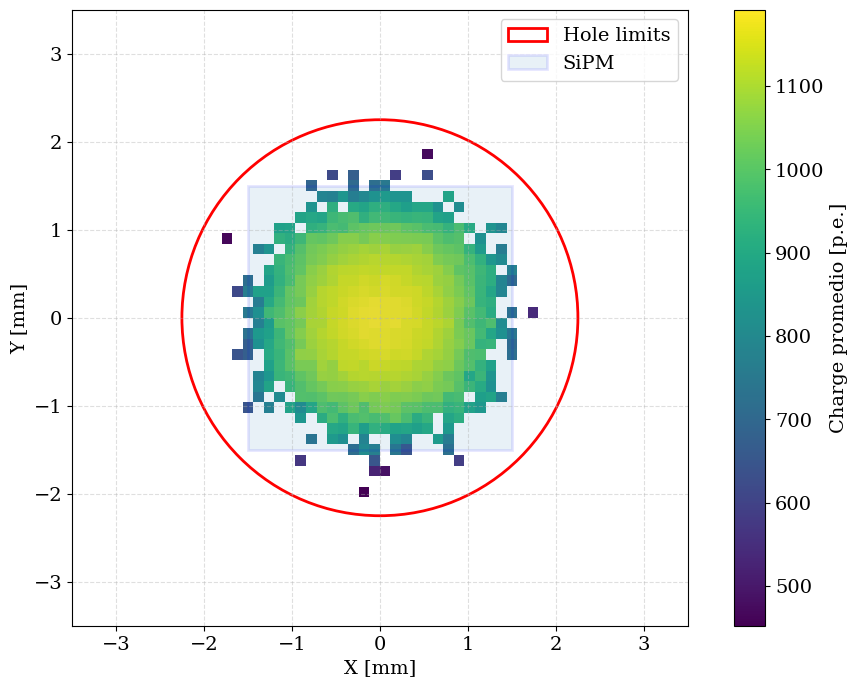

In [23]:
import numpy as np
from scipy.stats import binned_statistic_2d

plt.figure(figsize=(12, 8))

# bordes de bin comunes para X e Y, mismo rango que usabas antes
bins = 50
x_edges = np.linspace(-3, 3, bins + 1)
y_edges = np.linspace(-3, 3, bins + 1)

# carga promedio por bin (statistic='mean'); bins vacíos -> NaN automáticamente
stat, xedges, yedges, _ = binned_statistic_2d(
    event_summary['x_position'],
    event_summary['y_position'],
    event_summary['charge_pe'],
    statistic='mean',
    bins=[x_edges, y_edges]
)

# opcional: replicar el cmin=1 -> ocultar bins con menos de 1 entrada (ya son NaN por defecto)
# si quieres exigir un mínimo distinto de eventos por bin, calcula el conteo aparte:
counts, _, _, _ = binned_statistic_2d(
    event_summary['x_position'],
    event_summary['y_position'],
    event_summary['charge_pe'],
    statistic='count',
    bins=[x_edges, y_edges]
)
stat[counts < 1] = np.nan

circle = plt.Circle((0, 0), radius=2.25, fill=False, edgecolor='red', linewidth=2, label='Hole limits')
if sipm_size == 3:
    square = plt.Rectangle((-1.5, -1.5), 3, 3, fill=True, alpha=0.1, edgecolor='blue', linewidth=2, label='SiPM')
else:
    square = plt.Rectangle((-3, -3), 6, 6, fill=True, alpha=0.1, edgecolor='blue', linewidth=2, label='SiPM')

# stat tiene shape (nx, ny); pcolormesh espera (ny, nx) -> transponemos
mesh = plt.pcolormesh(xedges, yedges, stat.T, cmap='viridis')

plt.gca().add_patch(circle)
plt.gca().add_patch(square)
plt.gca().set_aspect('equal')
plt.colorbar(mesh, label='Charge promedio [p.e.]')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')
plt.legend()
plt.grid(True, alpha=0.4, linestyle='--')
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/charge_distribution_xy_{mode}_{sipm_size}mm.png')
plt.show()

In [24]:
event_summary.charge_pe/df_hits.photons_generated

0       0.019094
1       0.019097
2       0.019003
3       0.016983
4       0.019117
          ...   
9995    0.020173
9996    0.018669
9997    0.018301
9998    0.019641
9999    0.017888
Length: 10000, dtype: float64

In [25]:
data_mapa = pd.DataFrame({'Z': event_summary.z_position, 'R': event_summary.radius, 'LCE': event_summary.charge_pe/df_hits.photons_generated})

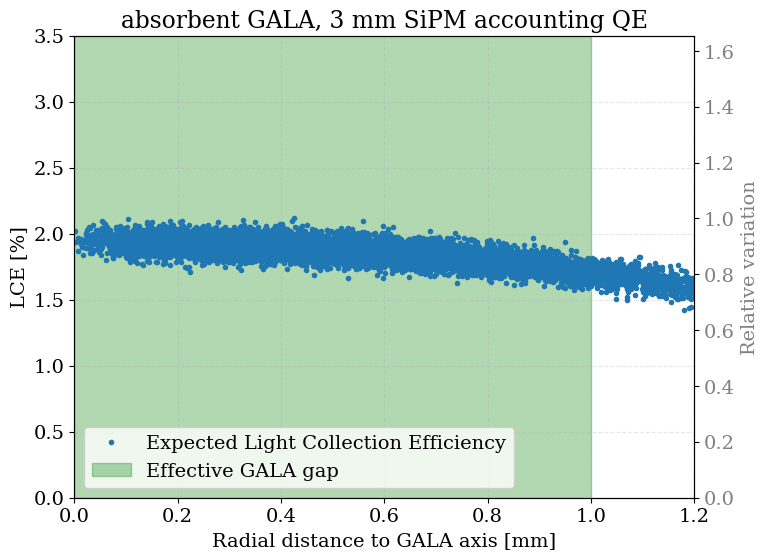

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(radius, event_summary.charge_pe/df_hits.photons_generated*100, '.', label='Expected Light Collection Efficiency')
ax1.fill_between((0, 1), (9.1, 9.1), alpha=0.3, color='green', label='Effective GALA gap')
ax1.set_title(f'{mode} GALA, {sipm_size} mm SiPM accounting QE')
ax1.set_xlabel('Radial distance to GALA axis [mm]')
ax1.set_ylabel('LCE [%]')

if mode == 'reflective':
    ax1.set_ylim(1,  4.0)

else:
    ax1.set_ylim(0, 3.5)


ax1.set_xlim(0, 1.2)
ax1.grid(True, alpha=0.3, linestyle='--')

lce_max = np.max(event_summary.charge_pe/df_hits.photons_generated*100)  # en %
lce_min = np.min(event_summary.charge_pe/df_hits.photons_generated*100)  # en %

ax2 = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2.set_ylim(ymin / lce_min, ymax / lce_max)
ax2.set_ylabel('Relative variation', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='lower left')
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/total_lce_{mode}_{sipm_size}mm2.png')

In [37]:
charge_collection_center = np.array(charge_collection_center)

In [38]:
counts, bins = np.histogram(charge_collection_center, bins = 50)
bincents = (bins[:-1] + bins[1:]) / 2

In [39]:
xplot = np.linspace(bincents[0], bincents[-1] + 30, 1000)

In [40]:
popt, pcov = curve_fit(gaussian, bincents, counts, p0 = (400, 300, 2200))

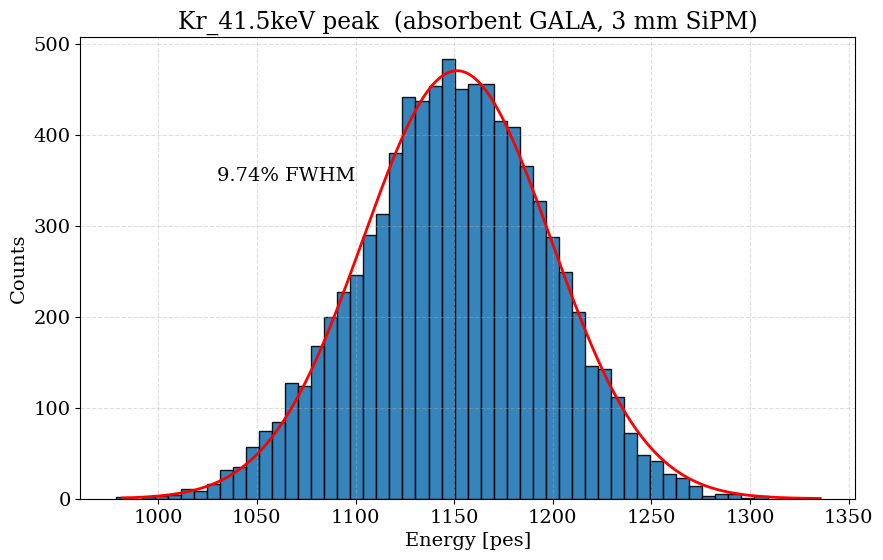

In [41]:
plt.hist(charge_collection_center, bins = 50, alpha = .9, edgecolor = 'black');
plt.plot(xplot, gaussian(xplot, *popt), 'r-', linewidth=2);
plt.annotate(f'{np.abs(energy_resolution_FWHM(popt[1], popt[2]))*100:.2f}% FWHM', xy = (1030, 350))
# plt.xlim(3750, 4700)
plt.xlabel('Energy [pes]');
plt.ylabel('Counts');
plt.grid(True, alpha = 0.4, linestyle='--');
plt.title(f'{event} peak  ({mode} GALA, {sipm_size} mm SiPM)');
if savefigs:
    plt.savefig(f'/Users/pablovazquez/GALA_hole/results/{field}kVcmbar/reflectivity_{switch}/{event}_energy_resolution_{sipm_size}mm_{mode}.png')

In [32]:
20475 / (33600/22.1)

13.467187500000001

In [33]:
15750*1.3

20475.0

In [34]:
popt[2]/29700*22.1

0.8567946525033003

In [35]:
charge_collections = [charge_collection_center, charge_collection_center_1, charge_collection_center_2, charge_collection_center_3, charge_collection_center_4, charge_collection_center_5, charge_collection_center_6, charge_collection_center_7]
effective_gap = [0.9, 1, 0.6, 1.2, 1.4, 0.5, 0.7, 0.8]
resolutions = []

for cc in charge_collections:
    counts, bins = np.histogram(cc, bins = 50)
    bincents = (bins[:-1] + bins[1:]) / 2
    popt, pcov = curve_fit(gaussian, bincents, counts, p0 = (400, 200, 9500))
    resolutions.append(energy_resolution_FWHM(popt[1], popt[2])*100)


/Users/pablovazquez/miniconda/envs/IC-3.8-2026-03-05/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


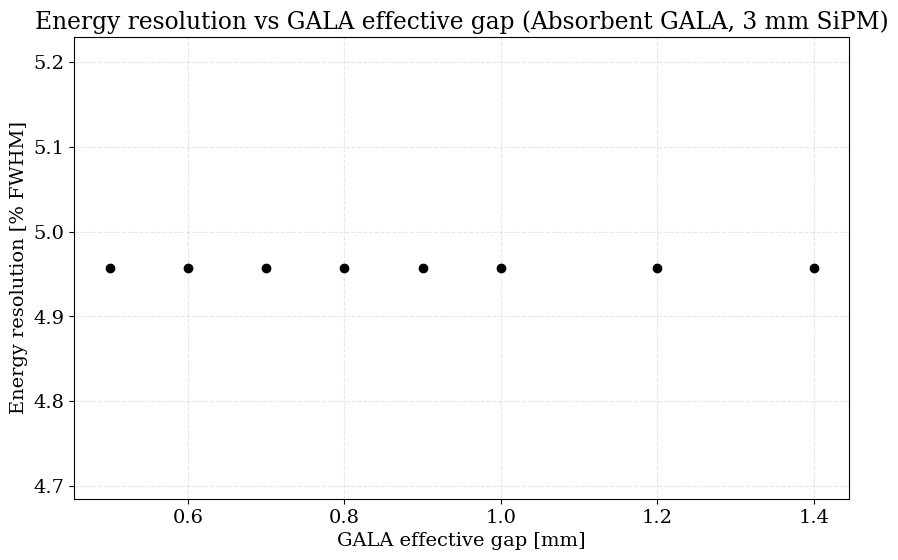

In [36]:
plt.plot(effective_gap, np.abs(resolutions), 'ko')
plt.xlabel('GALA effective gap [mm]');
plt.ylabel('Energy resolution [% FWHM]');
plt.title('Energy resolution vs GALA effective gap (Absorbent GALA, 3 mm SiPM)');
plt.grid(True, alpha = 0.3, linestyle = '--')
# plt.savefig('/Users/pablovazquez/GALA_hole/results/energy_resolution_vs_effective_gap_absorbent_correctedRadius_1.8kVcmbar_6mmSiPM.png')